In [1]:
# 1. Importer les librairies nécessaires
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples

---
Téléchargement des données

In [ ]:
# 2. Télécharger les données BTCUSDT (Bitcoin contre USDT)
# On prend les données sur 2 ans en daily
#df = yf.download('BTC-USD', period='12mo', interval='4h')
df = pd.read_parquet('bitcoin_data.parquet')
df.columns = df.columns.droplevel(1)
df = df.dropna()
df.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Datetime,,,,,
2024-07-16 12:00:00+00:00,64916.214844,64973.222656,63839.839844,63845.144531,0
2024-07-16 16:00:00+00:00,65092.402344,65161.210938,64233.820312,64906.964844,722722816
2024-07-16 20:00:00+00:00,65128.675781,65354.339844,64207.875000,65194.871094,418992128
2024-07-17 00:00:00+00:00,65762.156250,66066.734375,65013.945312,65091.832031,1531060224
2024-07-17 04:00:00+00:00,65306.738281,65994.601562,65268.046875,65735.546875,0


In [8]:
df = df[:'2025-07-01']

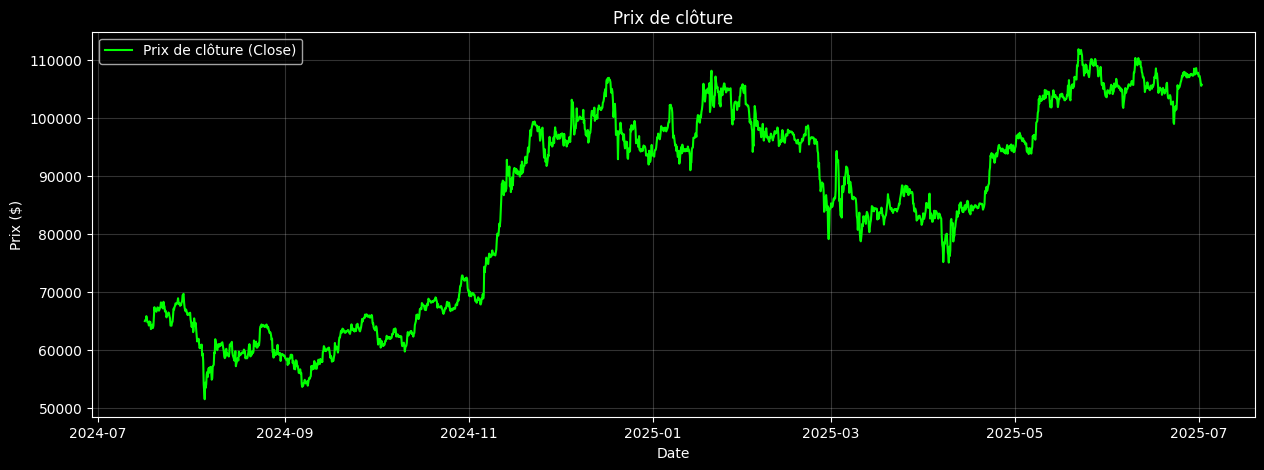

In [9]:
# 1. Visualiser les prix de clôture
plt.style.use('dark_background')
plt.figure(figsize=(15,5))
plt.plot(df['Close'], label='Prix de clôture (Close)', color='#00ff00')
plt.title('Prix de clôture', color='white')
plt.xlabel('Date', color='white')
plt.ylabel('Prix ($)', color='white')
plt.grid(True, alpha=0.2)
plt.legend(facecolor='black', labelcolor='white')
plt.gca().set_facecolor('black')
plt.show()

In [25]:
# 1. Préparer les données pour KMeans
# On va clusteriser les prix de clôture, pondérés par le volume
X = df[['Close']].values.reshape(-1, 1)  # Reshape to 2D array
weights = df['Volume'].values.reshape(-1)  # Ensure weights is 1D

# 4. Choisir le meilleur nombre de clusters
best_n_clusters = 4
print(f"Meilleur nombre de clusters : {best_n_clusters}")

# 5. Appliquer KMeans avec le meilleur nombre de clusters
kmeans = KMeans(n_clusters=best_n_clusters, random_state=42)
df['Cluster'] = kmeans.fit_predict(X, sample_weight=weights)
df['Cluster_center'] = kmeans.cluster_centers_[df['Cluster'], 0]

for i in range(best_n_clusters):
    mask = df['Cluster'] == i
    min_val = df.loc[mask, 'Close'].min()
    max_val = df.loc[mask, 'Close'].max()
    center = kmeans.cluster_centers_[i][0]
    df.loc[mask, f'Cluster_{i}_min'] = min_val
    df.loc[mask, f'Cluster_{i}_max'] = max_val
    df.loc[mask, f'Cluster_{i}_center'] = center

# Trier les clusters par leur centre pour faciliter le calcul des intersections
sorted_centers = sorted([(i, center[0]) for i, center in enumerate(kmeans.cluster_centers_)], 
                       key=lambda x: x[1])


Meilleur nombre de clusters : 4


/var/folders/jf/b0f7qprs3qv5hn8d5f4ffv_80000gn/T/ipykernel_88277/1279639144.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = kmeans.fit_predict(X, sample_weight=weights)
/var/folders/jf/b0f7qprs3qv5hn8d5f4ffv_80000gn/T/ipykernel_88277/1279639144.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster_center'] = kmeans.cluster_centers_[df['Cluster'], 0]


In [26]:
df.head()

Price,Close,High,Low,Open,Volume,Cluster,Cluster_center,Cluster_0_min,Cluster_0_max,Cluster_0_center,...,Cluster_1_center,Cluster_2_min,Cluster_2_max,Cluster_2_center,Cluster_3_min,Cluster_3_max,Cluster_3_center,Cluster_4_min,Cluster_4_max,Cluster_4_center
Datetime,,,,,,,,,,,,,,,,,,,,,
2024-07-16 12:00:00+00:00,64916.214844,64973.222656,63839.839844,63845.144531,0,1,68373.822222,NaN,NaN,NaN,...,68373.822222,51435.578125,72787.375,62430.360315,NaN,NaN,NaN,NaN,NaN,NaN
2024-07-16 16:00:00+00:00,65092.402344,65161.210938,64233.820312,64906.964844,722722816,1,68373.822222,NaN,NaN,NaN,...,68373.822222,51435.578125,72787.375,62430.360315,NaN,NaN,NaN,NaN,NaN,NaN
2024-07-16 20:00:00+00:00,65128.675781,65354.339844,64207.875000,65194.871094,418992128,1,68373.822222,NaN,NaN,NaN,...,68373.822222,51435.578125,72787.375,62430.360315,NaN,NaN,NaN,NaN,NaN,NaN
2024-07-17 00:00:00+00:00,65762.156250,66066.734375,65013.945312,65091.832031,1531060224,1,68373.822222,NaN,NaN,NaN,...,68373.822222,51435.578125,72787.375,62430.360315,NaN,NaN,NaN,NaN,NaN,NaN
2024-07-17 04:00:00+00:00,65306.738281,65994.601562,65268.046875,65735.546875,0,1,68373.822222,NaN,NaN,NaN,...,68373.822222,51435.578125,72787.375,62430.360315,NaN,NaN,NaN,NaN,NaN,NaN


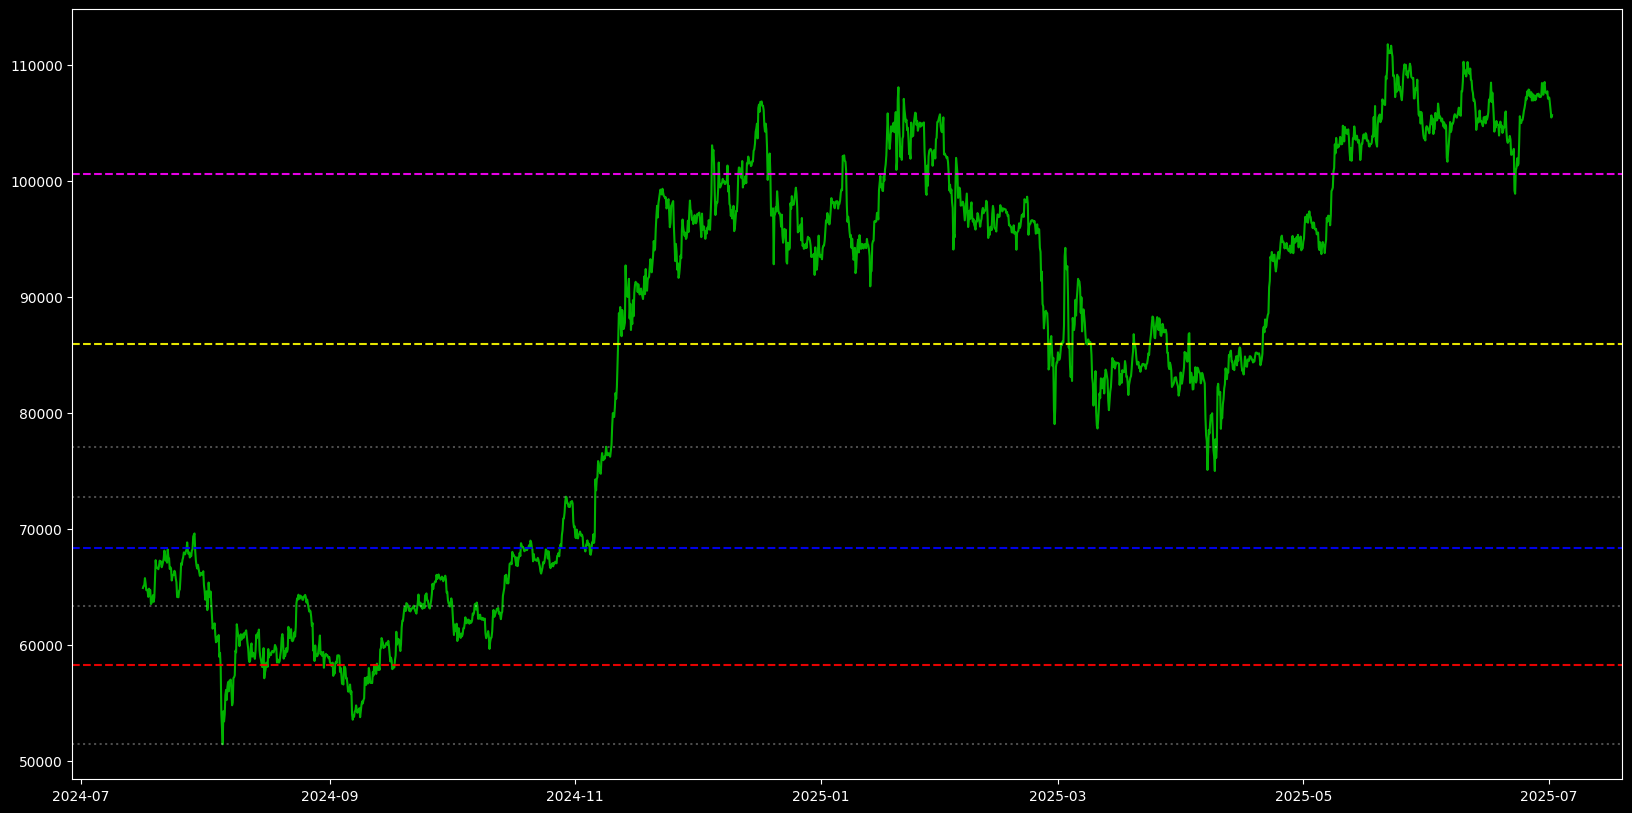

In [28]:
# Visualiser les prix de clôture avec les clusters
plt.style.use('dark_background')
plt.figure(figsize=(20,10))

# Plot prix de clôture
plt.plot(df['Close'], label='Prix de clôture (Close)', color='#00ff00', alpha=0.7)

# Plot les centres des clusters
colors = ['#ff0000', '#0000ff', '#ffff00', '#ff00ff']
for i, (cluster_idx, center) in enumerate(sorted_centers):
    cluster_data = df[df['Cluster'] == cluster_idx]
    plt.axhline(y=center, color=colors[i], linestyle='--', alpha=0.9, 
                label=f'Centre cluster {cluster_idx}')
    
    # Plot les min/max de chaque cluster une seule fois
    plt.axhline(y=df[f'Cluster_{cluster_idx}_min'].iloc[0], color='white', 
                linestyle=':', alpha=0.3)
    plt.axhline(y=df[f'Cluster_{cluster_idx}_max'].iloc[0], color='white', 
                linestyle=':', alpha=0.3)



---
Comment trouver le nombre de clusters ?

---

In [ ]:
def rolling_support_resistance(df, window_size=300, k_range=range(2, 7), threshold=0.01):
    if df.empty:
        print("DataFrame is empty. Returning as is.")
        return df

    sr_zone = [False] * len(df)
    best_ks = [np.nan] * len(df)
    centers_list = [None] * len(df)

    for i in range(window_size, len(df)):
        window = df.iloc[i-window_size:i]
        X = window[['Close']].values.reshape(-1, 1)

        # Find best K
        best_k = None
        best_score = -np.inf
        for k in k_range:
            kmeans = KMeans(n_clusters=k, random_state=42)
            labels = kmeans.fit_predict(X)
            sil_samples = silhouette_samples(X, labels)
            mean_sil = np.mean(sil_samples)
            if mean_sil > best_score:
                best_score = mean_sil
                best_k = k

        # Fit KMeans with best K
        kmeans = KMeans(n_clusters=best_k, random_state=42)
        labels = kmeans.fit_predict(X)
        centers = np.array(kmeans.cluster_centers_).flatten()
        centers = np.sort(centers)
        centers_list[i] = centers.tolist()
        best_ks[i] = best_k

        # Check if current price is near any center
        current_price = float(df.iloc[i]['Close'])
        price_range = float(window['Close'].max() - window['Close'].min())
        distances = np.abs(centers - current_price)
        near_center = np.any(distances < threshold * price_range)
        sr_zone[i] = near_center

    df = df.copy()
    df['SR_zone'] = sr_zone
    df['SR_best_k'] = best_ks
    df['SR_centers'] = pd.Series(centers_list, dtype=object)
    return df

In [ ]:
df = rolling_support_resistance(df)

In [ ]:
# Plot price with support/resistance zones highlighted
plt.figure(figsize=(15, 8))

# Plot price line
plt.plot(df.index, df['Close'], label='Price', color='blue', alpha=0.7)

# Highlight SR zones
sr_mask = df['SR_zone']
plt.scatter(df[sr_mask].index, df[sr_mask]['Close'], 
           color='yellow', label='Support/Resistance Zone')

# Plot SR centers where they exist
for i, centers in enumerate(df['SR_centers']):
    if isinstance(centers, list) and centers:
        # Draw horizontal lines for each center
        for center in centers:
            plt.axhline(y=center, color='green', 
                       xmin=i/len(df), xmax=(i+1)/len(df))

plt.title('Bitcoin Price with Support/Resistance Zones')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
